In [1]:
import sys
import os
import pandas as pd

# Add the parent directory (simcode) to sys.path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from src.dgp import GaussianNetwork
from src.helper_functions.simulation_functions import run_simulation
from src.helper_functions.analyse_functions import aggregate_results
import re
from src.helper_functions.plot_functions import (
    plot_grid,
    plot_with_bands,
    plot_heatmap,
    plot_scatter_markers,
)
import ast
import numpy as np
from functools import partial

In [2]:
import matplotlib.pyplot as plt


rcparams = {
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 9,
    "figure.titlesize": 11,
    "legend.fontsize": 10,
    "legend.title_fontsize": 10.5,
    "lines.linewidth": 1,
    "axes.linewidth": 0.5,
    "axes.facecolor": "white",
    "axes.grid": False,
    "lines.markersize": 3,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
}

plt.rcParams.update(rcparams)

In [3]:
linestyles = {
    "RV": "-",
    "DC": "--",
    "QAP": "-.",
    "CVM": ":",
}

colors = {
    "DC": "#4285F4",  # Blue
    "CVM": "#EA4335",  # Red
    "QAP": "#38761D",  # Dark Green
    "RV": "#FBBC05",  # Yellow
}

marker_map = {"DC": "x", "CVM": "o", "QAP": "D", "RV": "v"}

plotting_function = partial(plot_with_bands, colors=colors, linestyles=linestyles)

In [4]:
results1 = pd.read_csv("simulation_results_20260511_1449.csv")

In [5]:
results_concat = results1.copy()

In [6]:
import re


def parse_config_string(s):
    # extract rough key-value pairs
    pairs = dict(re.findall(r"'([^']+)':\s*([^,}]+)", s))

    # extract method class specifically from the 'method' field (not globally)
    method_val_match = re.search(r"'method':\s*(.*?)(?=,\s*'[^']+':|$|})", s, re.DOTALL)
    method_class, test_function = None, None

    if method_val_match:
        method_val = method_val_match.group(1)
        cm = re.search(r"<class '([^']+)'>", method_val)
        if cm:
            method_class = cm.group(1).split(".")[-1]
        # fm = re.search(r"test_function=<function ([^ ]+)", method_val)
        # if fm:
        #     test_function = fm.group(1)
        approx = re.search(r"approximation=\'(\w+)\'", method_val)
        if approx:
            pairs["approximation"] = approx.group(1)

    if method_class == "PermutationTest" and test_function:
        method = f"{method_class}_{test_function}"
    else:
        method = method_class
    pairs["method"] = method

    # extract solver: handle both plain string and <function Name at 0x...>
    solver_match = re.search(r"'solver':\s*<function ([^ ]+)", s)
    if solver_match:
        pairs["solver"] = solver_match.group(1)

    # clean up np.int64/np.float64 wrappers
    for k, v in pairs.items():
        nm = re.match(r"np\.\w+\(([^)]+)\)", str(v).strip())
        if nm:
            pairs[k] = nm.group(1)

    # extract degree
    pairs["degree"] = (
        re.search(r"degree=(\d+)", s).group(1)
        if re.search(r"degree=(\d+)", s)
        else "NA"
    )

    return pairs

In [7]:
def parse_result_string(s):
    # remove numpy scalar wrappers
    s_clean = re.sub(r"np\.float64\((.*?)\)", r"\1", s)

    return ast.literal_eval(s_clean)

In [8]:
results = results_concat.copy()
results["args"] = results["args"].apply(parse_config_string)

In [9]:
results["ComputeAll"] = results["ComputeAll"].apply(parse_result_string)

In [10]:
results["density"] = results["density"].apply(
    lambda x: re.findall(r"np\.float64\((.*?)\)", x)
)
results["density_A"] = results["density"].apply(lambda x: x[0])
results["density_B"] = results["density"].apply(lambda x: x[1])

In [11]:
results["edge_var"] = results["args"].apply(lambda x: x.get("edge_var", "NA"))
results["n"] = results["args"].apply(lambda x: x.get("n", "NA"))
results["k"] = results["args"].apply(lambda x: x.get("k", "NA"))
results["method"] = results["args"].apply(lambda x: x.get("method", "NA").strip("'"))
results["solver"] = results["args"].apply(lambda x: x.get("solver", "NA").strip("'"))
results["copula"] = results["args"].apply(
    lambda x: x.get("copula_type", "NA").strip("'")
)
results["dgp_name"] = results["args"].apply(
    lambda x: x.get("dgp_name", "NA").strip("'")
)
results["marginals"] = results["args"].apply(
    lambda x: x.get("marginals", "NA").strip("'")
)
results["rho"] = results["args"].apply(
    lambda x: x.get("rho", "NA").replace("np.float64(", "").replace(")", "")
)
results["rho"] = results["rho"].apply(lambda x: float(x))
results["degree"] = results["args"].apply(
    lambda x: x.get("degree", "NA").replace("np.int64(", "").replace(")", "")
)
results["approximation"] = results["args"].apply(
    lambda x: x.get("approximation", "NA").strip("'")
)
results["use_true_latent"] = results["args"].apply(
    lambda x: x.get("use_true_latent", "NA") if "use_true_latent" in x else "NA"
)

In [12]:
results["n"] = results["n"].apply(
    lambda x: int(x.replace("np.int64(", "").replace(")", ""))
)
results["k"] = results["k"].apply(
    lambda x: int(x.replace("np.int64(", "").replace(")", ""))
)

In [13]:
results_all = results.copy()

In [14]:
results_all["dgp"] = results_all["args"].apply(lambda x: x.get("dgp_name", "NA"))
results_all["dgp_name"] = [x.split("_")[0].strip("'") for x in results_all["dgp"]]
results_all["copula"] = [x.split("_")[1].strip("'") for x in results_all["dgp"]]

In [15]:
# temp = results_all[results_all['method']=='QAP'].copy()

# temp["dgp"] = temp["args"].apply(lambda x: x.get("dgp_name", "NA"))
# temp['dgp_name'] =  [x.split('_')[0].strip("'") for x in temp['dgp']]
# temp['copula'] =  [x.split('_')[1].strip("'") for x in temp['dgp']]

# results_all[results_all['method']=='QAP']=temp.copy()

In [16]:
# temp = results_all[results_all['method']=='ObservedCVM'].copy()

# temp["dgp"] = temp["args"].apply(lambda x: x.get("dgp_name", "NA"))
# temp['dgp_name'] =  [x.split('_')[0].strip("'") for x in temp['dgp']]
# temp['copula'] =  [x.split('_')[1].strip("'") for x in temp['dgp']]
# # temp['method'] = temp['method'] + '_' +temp['degree']
# results_all[results_all['method']=='ObservedCVM']=temp.copy()

In [17]:
results_all["RelativeFrobeniusNorm_x"] = results_all["ComputeAll"].apply(
    lambda x: x.get("RelativeFrobeniusNorm_x", np.nan)
)
results_all["RelativeFrobeniusNorm_z"] = results_all["ComputeAll"].apply(
    lambda x: x.get("RelativeFrobeniusNorm_z", np.nan)
)

results_all["ProcrustesDistance_x"] = results_all["ComputeAll"].apply(
    lambda x: x.get("ProcrustesDistance_x", np.nan)
)
results_all["ProcrustesDistance_z"] = results_all["ComputeAll"].apply(
    lambda x: x.get("ProcrustesDistance_z", np.nan)
)

results_all["FalseRejection"] = results_all["ComputeAll"].apply(
    lambda x: x["FalseRejection"]
)
results_all["TrueRejection"] = results_all["ComputeAll"].apply(
    lambda x: x["TrueRejection"]
)
results_all["Rejection"] = results_all["ComputeAll"].apply(lambda x: x["Rejection"])

In [18]:
results_all["avg_rel_frob_x"] = results_all.groupby(
    ["n", "method", "marginals", "copula", "dgp_name"]
)["RelativeFrobeniusNorm_x"].transform("mean")

results_all["avg_proc_dist_x"] = results_all.groupby(
    ["n", "method", "marginals", "copula", "dgp_name"]
)["ProcrustesDistance_x"].transform("mean")

In [19]:
results_all["permutation_type"] = results_all["RelativeFrobeniusNorm_x"].apply(
    lambda x: "observed" if np.isnan(x) else "latent"
)
results_all["method"] = results_all["method"].replace(
    {
        "DiffusionCorrelation": "DC",
        "RVPermutationTest": "RV",
        "ObservedCVM": "CVM",
    }
)
results_all["marginals"] = results_all["marginals"].replace(
    {"chi 5": "chi df=5", "t 5": "t df=5", "uniform -1 1": "unif(-1, 1)"}
)
results_all.rename(columns={"TrueRejection": "Power"}, inplace=True)

In [20]:
results_all = results_all[results_all["edge_var"] == "3"]
results_all = results_all[~results_all["degree"].isin(["1", "3"])]

### Defining different aggregations

In [21]:
# based on dgp
results_gaussian = results_all[(results_all["dgp_name"] == "GaussianNetwork")].copy()
results_bernoulli = results_all[(results_all["dgp_name"] == "BernoulliNetwork")].copy()

In [22]:
# based on rho + dgp
results_null_gaussian = results_gaussian[(results_gaussian["rho"] == 0.0)].copy()
results_alt_05_gaussian = results_gaussian[(results_gaussian["rho"] == 0.5)].copy()
results_alt_02_gaussian = results_gaussian[(results_gaussian["rho"] == 0.2)].copy()

results_null_bernoulli = results_bernoulli[(results_bernoulli["rho"] == 0.0)].copy()
results_alt_05_bernoulli = results_bernoulli[(results_bernoulli["rho"] == 0.5)].copy()
results_alt_02_bernoulli = results_bernoulli[(results_bernoulli["rho"] == 0.2)].copy()

## Type I error

**Ensure type I error is controlled at 5%**

In [23]:
agg_null_gaussian = aggregate_results(
    results_null_gaussian,
    y_axis="FalseRejection",
    x_axis="n",
    factors=["marginals", "method", "approximation", 'use_true_latent'],
)

agg_null_bernoulli = aggregate_results(
    results_null_bernoulli,
    y_axis="FalseRejection",
    x_axis="n",
    factors=["marginals", "method", "approximation", 'use_true_latent'],
)

agg_null_gaussian_frob = aggregate_results(
    results_null_gaussian,
    y_axis="FalseRejection",
    x_axis="avg_rel_frob_x",
    factors=["marginals", "method", "approximation", 'use_true_latent'],
)
agg_null_bernoulli_frob = aggregate_results(
    results_null_bernoulli,
    y_axis="FalseRejection",
    x_axis="avg_rel_frob_x",
    factors=["marginals", "method", "approximation", 'use_true_latent'],
)

agg_null_gaussian_proc = aggregate_results(
    results_null_gaussian,
    y_axis="FalseRejection",
    x_axis="avg_proc_dist_x",
    factors=["marginals", "method", "approximation", 'use_true_latent'],
)
agg_null_bernoulli_proc = aggregate_results(
    results_null_bernoulli,
    y_axis="FalseRejection",
    x_axis="avg_proc_dist_x",
    factors=["marginals", "method", "approximation", 'use_true_latent'],
)

In [24]:
rcparams = {
    "text.usetex": False,  # Disabled LaTeX rendering
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "Times New Roman", "DejaVu Serif"],
    "font.weight": "normal",  # Bolds all general text
    "font.size": 17,
    "figure.titlesize": 17,
    "figure.titleweight": "normal",  # Bolds the main figure title
    "legend.fontsize": 17,
    "legend.title_fontsize": 17,
    "lines.linewidth": 1,
    "axes.linewidth": 0.5,
    "axes.labelweight": "normal",  # Bolds axis labels (x, y)
    "axes.titleweight": "normal",  # Bolds axis titles
    "axes.facecolor": "white",
    "axes.grid": False,
    "lines.markersize": 3,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
}

plt.rcParams.update(rcparams)

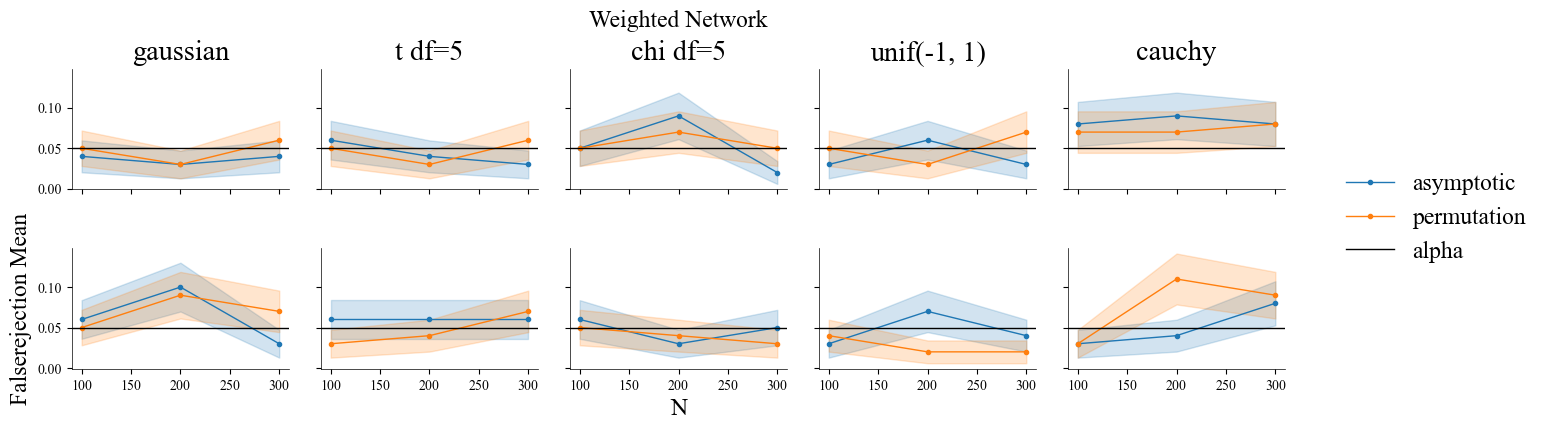

In [31]:
temp = agg_null_gaussian.copy()

plot_grid(
    grouped_stats=temp,
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="FalseRejection_mean",
    factors=["approximation", "marginals", 'use_true_latent'],
    height=2,
    se_bands="FalseRejection_sem",
    share_x=True,
    share_y=True,
    title="Weighted Network",
    hline=0.05,
    hline_name="alpha",
    show_row_titles=False,
    show_col_names=False,
    col_order=["gaussian", "t df=5", "chi df=5", "unif(-1, 1)", "cauchy"],
)

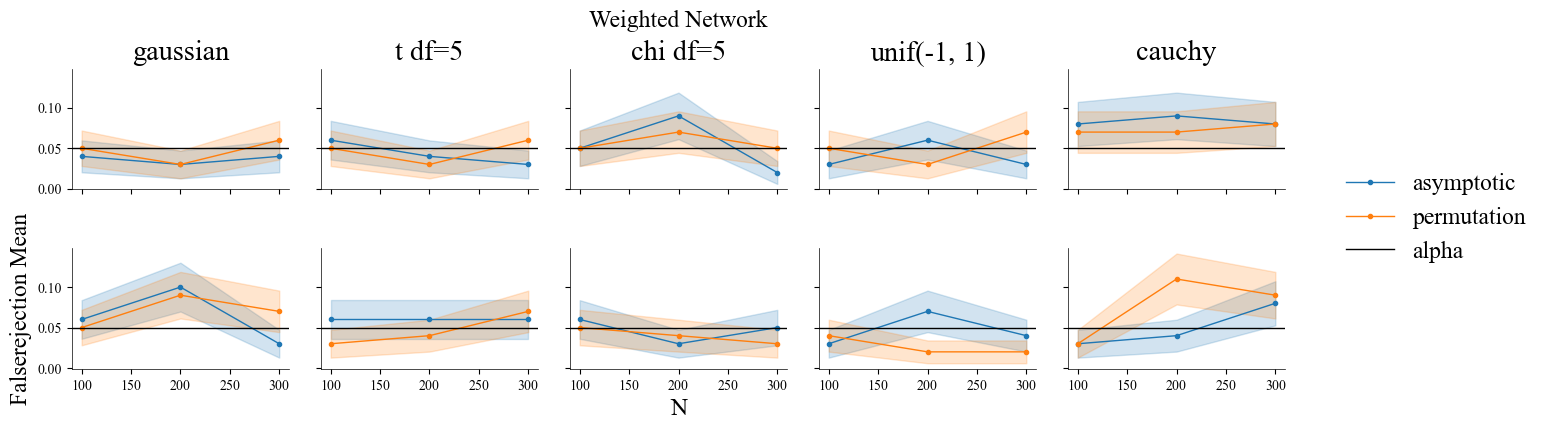

In [32]:
temp = agg_null_gaussian.copy()

plot_grid(
    grouped_stats=temp,
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="FalseRejection_mean",
    factors=["approximation", "marginals", 'use_true_latent'],
    height=2,
    se_bands="FalseRejection_sem",
    share_x=True,
    share_y=True,
    title="Weighted Network",
    hline=0.05,
    hline_name="alpha",
    show_row_titles=False,
    show_col_names=False,
    col_order=["gaussian", "t df=5", "chi df=5", "unif(-1, 1)", "cauchy"],
)

flipping


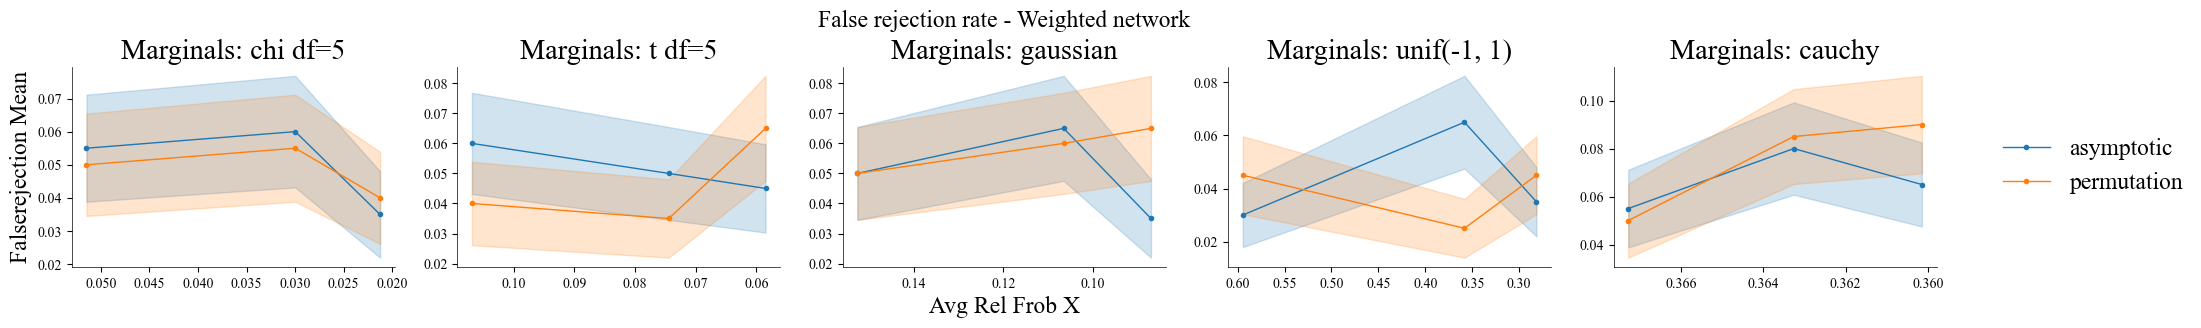

In [27]:
temp = agg_null_gaussian_frob.copy()

plot_grid(
    grouped_stats=temp,
    plotting_function=plot_with_bands,
    x_axis="avg_rel_frob_x",
    y_axis="FalseRejection_mean",
    factors=["approximation", "marginals"],
    height=3,
    se_bands="FalseRejection_sem",
    share_x=False,
    share_y=False,
    title="False rejection rate - Weighted network",
    flip_x_axis=True,
)

In [28]:
# temp = agg_null_gaussian_proc.copy()

# plot_grid(
#     grouped_stats=temp,
#     plotting_function=plotting_function,
#     x_axis="avg_proc_dist_x",
#     y_axis="FalseRejection_mean",
#     factors=["method", "marginals",],
#     height=3,
#     se_bands="FalseRejection_sem",
#     share_x=False,
#     share_y=False,
#     title="False rejection rate - Weighted network",
#     flip_x_axis=True,
# )

flipping


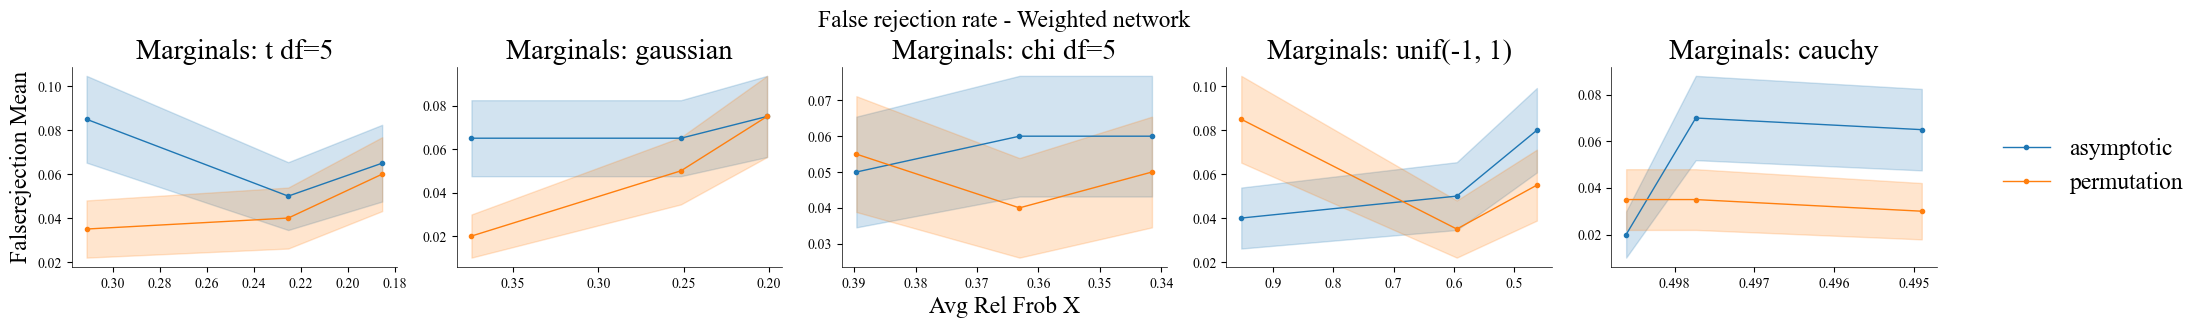

In [29]:
temp = agg_null_bernoulli_frob.copy()

plot_grid(
    grouped_stats=temp,
    plotting_function=plot_with_bands,
    x_axis="avg_rel_frob_x",
    y_axis="FalseRejection_mean",
    factors=["approximation", "marginals"],
    height=3,
    se_bands="FalseRejection_sem",
    share_x=False,
    share_y=False,
    title="False rejection rate - Weighted network",
    flip_x_axis=True,
)

In [30]:
# temp = agg_null_bernoulli_proc.copy()

# plot_grid(
#     grouped_stats=temp,
#     plotting_function=plotting_function,
#     x_axis="avg_proc_dist_x",
#     y_axis="FalseRejection_mean",
#     factors=["method", "marginals",],
#     height=3,
#     se_bands="FalseRejection_sem",
#     share_x=False,
#     share_y=False,
#     title="False rejection rate - Binary network",
#     flip_x_axis=Tru
# )

### Power

In [33]:
agg_alt_02_gaussian = aggregate_results(
    results_alt_02_gaussian,
    y_axis="Power",
    x_axis="n",
    factors=["marginals", "method", "copula", "approximation", 'use_true_latent'],
)
agg_alt_02_bernoulli = aggregate_results(
    results_alt_02_bernoulli,
    y_axis="Power",
    x_axis="n",
    factors=["marginals", "method", "copula", "approximation", 'use_true_latent'],
)

agg_alt_02_gaussian_frob = aggregate_results(
    results_alt_02_gaussian,
    y_axis="Power",
    x_axis="avg_rel_frob_x",
    factors=["marginals", "method", "copula", "approximation", 'use_true_latent'],
)

agg_alt_02_bernoulli_frob = aggregate_results(
    results_alt_02_bernoulli,
    y_axis="Power",
    x_axis="avg_rel_frob_x",
    factors=["marginals", "method", "copula", "approximation", 'use_true_latent'],
)

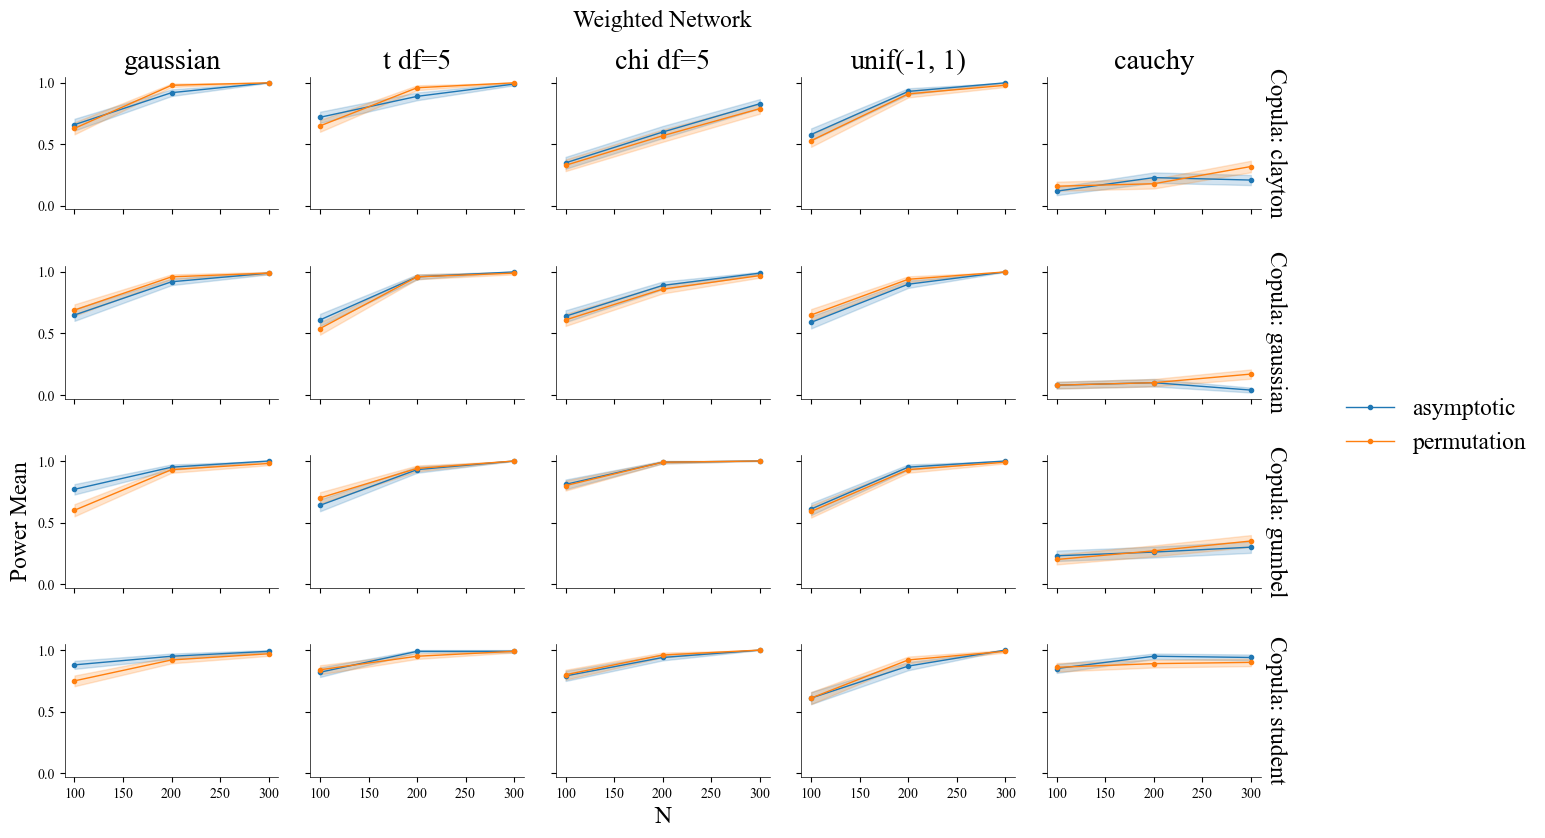

In [ ]:
temp = agg_alt_02_gaussian[agg_alt_02_gaussian['use_true_latent']=='True'].copy()

plot_grid(
    grouped_stats=temp,
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="Power_mean",
    factors=["approximation", "marginals", "copula"],
    height=2,
    se_bands="Power_sem",
    share_x=True,
    share_y=True,
    title="Weighted Network - True latent positions",
    show_row_titles=True,
    show_col_names=False,
    col_order=["gaussian", "t df=5", "chi df=5", "unif(-1, 1)", "cauchy"],
)

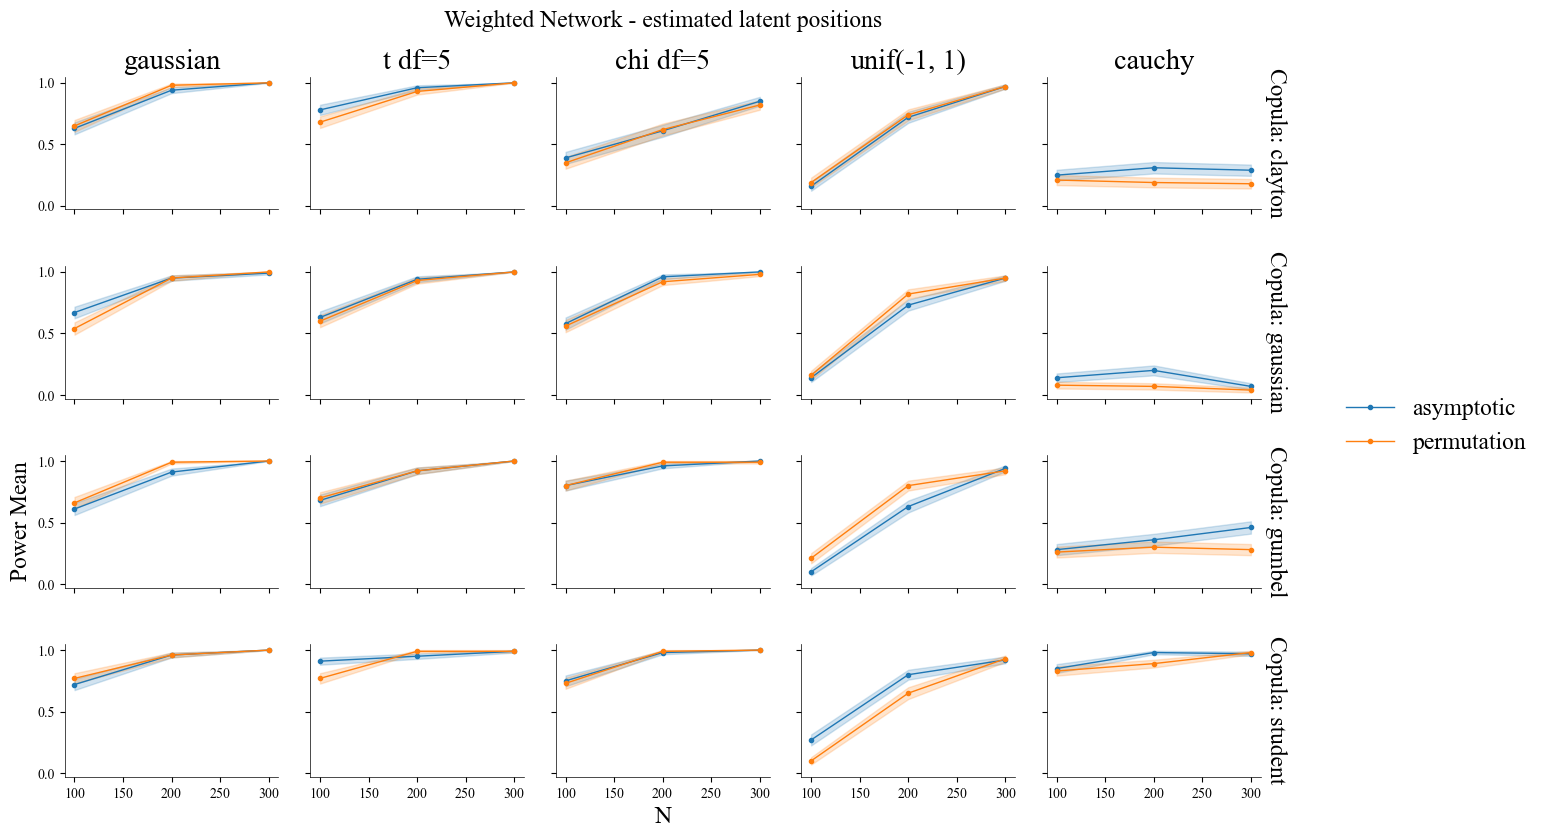

In [36]:
temp = agg_alt_02_gaussian[agg_alt_02_gaussian['use_true_latent']=='False'].copy()

plot_grid(
    grouped_stats=temp,
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="Power_mean",
    factors=["approximation", "marginals", "copula"],
    height=2,
    se_bands="Power_sem",
    share_x=True,
    share_y=True,
    title="Weighted Network - estimated latent positions",
    show_row_titles=True,
    show_col_names=False,
    col_order=["gaussian", "t df=5", "chi df=5", "unif(-1, 1)", "cauchy"],
)

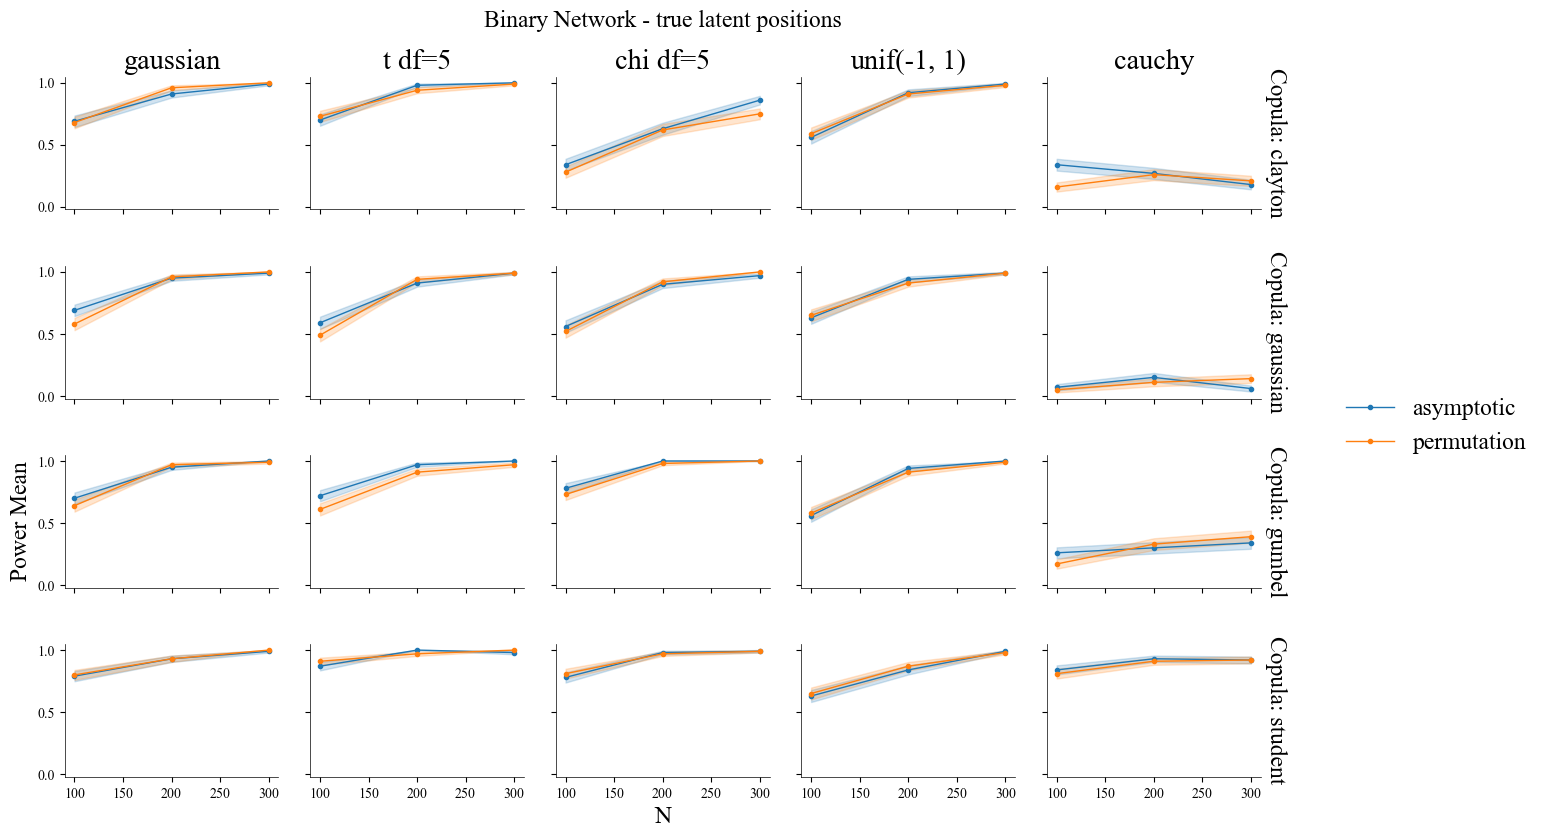

In [38]:
temp = agg_alt_02_bernoulli[agg_alt_02_bernoulli['use_true_latent']=='True'].copy()

plot_grid(
    grouped_stats=temp,
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="Power_mean",
    factors=["approximation", "marginals", "copula"],
    height=2,
    se_bands="Power_sem",
    share_x=True,
    share_y=True,
    title="Binary Network - true latent positions",
    show_row_titles=True,
    show_col_names=False,
    col_order=["gaussian", "t df=5", "chi df=5", "unif(-1, 1)", "cauchy"],
)

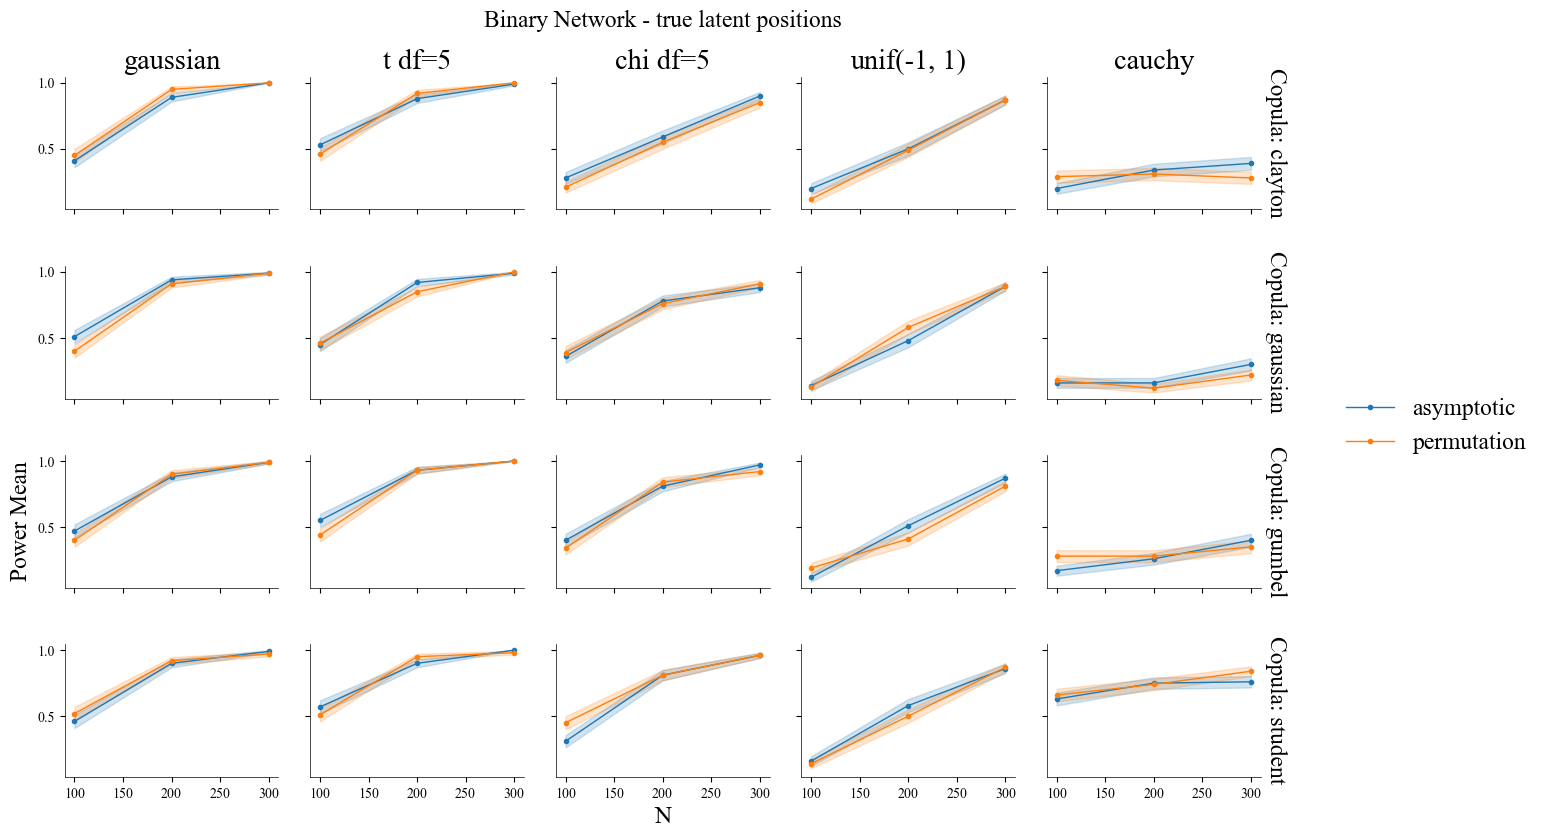

In [39]:
temp = agg_alt_02_bernoulli[agg_alt_02_bernoulli['use_true_latent']=='False'].copy()

plot_grid(
    grouped_stats=temp,
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="Power_mean",
    factors=["approximation", "marginals", "copula"],
    height=2,
    se_bands="Power_sem",
    share_x=True,
    share_y=True,
    title="Binary Network - true latent positions",
    show_row_titles=True,
    show_col_names=False,
    col_order=["gaussian", "t df=5", "chi df=5", "unif(-1, 1)", "cauchy"],
)